# Maximally-localized Wannier functions for a selected range of bands

`h.get_wannier_hamiltonian(bands=[a,b], nk=...)` builds maximally-localized Wannier functions
(MLWFs) for a fixed, contiguous range of bands $[a,b]$ (0-indexed, both ends inclusive,
Wannierized jointly as one group; there is no band disentanglement), via the `wannierpy`
pure-Python Wannier90 port bundled at `src/pyqula/wanniertk/wannierpy/`. The functions are
found by minimizing the Marzari-Vanderbilt total spread functional

$$\Omega = \sum_n \left[\langle r^2\rangle_n - \langle \mathbf{r}\rangle_n^2\right]$$

over gauge choices consistent with the selected bands, and the method returns a new, smaller
`Hamiltonian` whose real-space hoppings exactly reproduce that band subspace on the
wannierization k-mesh (see the next notebook).

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry

Number of Wannier functions: 1
Wannier centres (Cartesian):
 [[5.00000000e-01 2.01420670e-17 6.50536337e-33]]
Wannier spreads: [0.32057843]
Total spread Omega: 0.32057842606619075


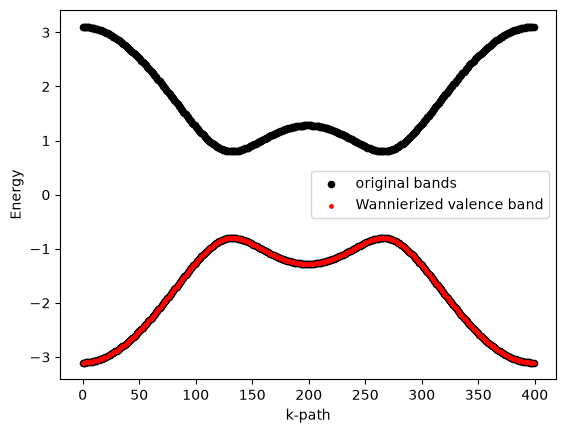

In [2]:
hwan = None
g = geometry.honeycomb_lattice()
h = g.get_hamiltonian(has_spin=False)
h.add_onsite([0.8,-0.8]) # sublattice potential opens a gap -- non-trivial valence band

# Wannierize just the lowest (valence) band -- bands=[0,0] selects band index 0 at
# every k-point of a 12x12 wannierization mesh
hwan = h.get_wannier_hamiltonian(bands=[0,0],nk=12)

print("Number of Wannier functions:",hwan.intra.shape[0])
print("Wannier centres (Cartesian):\n",hwan.wannier_centres)
print("Wannier spreads:",hwan.wannier_spreads)
print("Total spread Omega:",hwan.wannier_spread_total)

(k,e) = h.get_bands(write=False)
(kw,ew) = hwan.get_bands(write=False)

plt.scatter(k,e,c="black",s=20,label="original bands")
plt.scatter(kw,ew,c="red",s=6,label="Wannierized valence band")
plt.xlabel("k-path")
plt.ylabel("Energy")
plt.legend()
plt.show()

The Wannier function itself is stored in `hwan.wannier_functions`, as its amplitude on every
orbital of the original lattice, cell by cell. Its weight $|W(\mathbf r)|^2$ on each site shows a
function centred on the sublattice with the lower onsite energy, with a small weight on its three
first neighbors and an exponential decay beyond them.

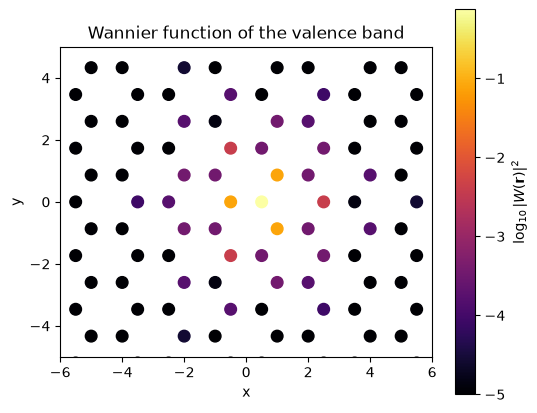

In [3]:
# real-space weight |W(r)|^2 of the valence-band Wannier function on every site
pos = [] ; w = []
for R,c in hwan.wannier_functions.items(): # c[o,n]: amplitude of Wannier function n on orbital o of cell R
    for o in range(len(g.r)):
        pos.append(R[0]*g.a1 + R[1]*g.a2 + g.r[o]) # position of orbital o in cell R
        w.append(np.abs(c[o,0])**2)
pos = np.array(pos) ; w = np.array(w)

plt.figure(figsize=(6,5))
plt.scatter(pos[:,0],pos[:,1],c=np.log10(w+1e-16),cmap="inferno",vmin=-5,s=70)
plt.colorbar(label=r"$\log_{10}|W(\mathbf{r})|^2$")
plt.xlim(-6,6) ; plt.ylim(-5,5) ; plt.gca().set_aspect("equal")
plt.xlabel("x") ; plt.ylabel("y")
plt.title("Wannier function of the valence band")
plt.show()